This jupiter notebook aims at replicating the results obtained on the evaluation set

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
def group_CV(x_train_val, y_train_val, splits, model, groups, scale=False):
    # costum function to perform grouped cross validation
    kf = GroupKFold(n_splits=splits)
    fold=1
    groups = groups
    all_train_mae = []
    all_val_mae = []
    all_R_train = []
    all_R_val = []
    
    for train_idx, val_idx in kf.split(x_train_val, y_train_val, groups):

        x_train = x_train_val[train_idx]
        y_train = y_train_val[train_idx]
        x_val = x_train_val[val_idx]
        y_val = y_train_val[val_idx]
        
        if scale:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_val = scaler.transform(x_val)

        model.fit(x_train, y_train)
        preds_train = model.predict(x_train)
        preds_val = model.predict(x_val)
        train_mae = mean_absolute_error(y_train, preds_train)
        val_mae = mean_absolute_error(y_val, preds_val)
        R_train = pearsonr(y_train, preds_train).statistic
        R_val = pearsonr(y_val, preds_val).statistic
        all_train_mae.append(train_mae)
        all_val_mae.append(val_mae)
        all_R_train.append(R_train)
        all_R_val.append(R_val)
        print(f'Fold {fold}/{splits}:  Train MAE: {train_mae} - Val MAE: {val_mae} - Ratio train/val: {(train_mae/val_mae)}')
        print(f'Fold {fold}/{splits}: Train R: {R_train} - Val R: {R_val} - Ratio train/val: {R_train/R_val}')

        fold += 1

    return np.vstack((np.array(all_train_mae), np.array(all_val_mae), np.array(all_R_train), np.array(all_R_val)))

In [ ]:
# read poses file
poses = pd.read_excel(r'Data/Poses.xlsx')
# read features
features = pd.read_csv(r'Data/features_train_and_evaluation_set.csv')
# split the features into train and evaluation set input matrix
X_train = features.loc[poses['Split'] == 'Train'].to_numpy()
X_eval = features.loc[poses['Split'] == 'Evaluation'].to_numpy()
# obtain training groups and train and evaluation y (RMSD)
groups = poses.loc[poses['Split'] == 'Train', 'Group'].to_numpy()
y_train = poses.loc[poses['Split'] == 'Train', 'RMSD'].to_numpy()
y_eval = poses.loc[poses['Split'] == 'Evaluation', 'RMSD'].to_numpy()

print(f'Shape of train features: {X_train.shape}')
print(f'Shape of evaluation features: {X_eval.shape}')
print(f'Shape of groups: {groups.shape}')
print(f'Shape of y train: {y_train.shape}')
print(f'Shape of y eval: {y_eval.shape}')

Shape of train features: (5083, 30)
Shape of evaluation features: (1771, 30)
Shape of groups: (5083,)
Shape of y train: (5083,)
Shape of y eval: (1771,)


In [17]:
# Now we are ready to perform the grouped cross-validation
results_cv = group_CV(X_train, y_train, 10, HistGradientBoostingRegressor(random_state=32), groups)

Fold 1/10:  Train MAE: 0.8198214213753621 - Val MAE: 1.6754705637423275 - Ratio train/val: 0.48930816160936347
Fold 1/10: Train R: 0.9458109487316928 - Val R: 0.7675523411752663 - Ratio train/val: 1.2322429337958625
Fold 2/10:  Train MAE: 0.8329742794937791 - Val MAE: 1.639421556686809 - Ratio train/val: 0.5080903542449323
Fold 2/10: Train R: 0.9455996291315806 - Val R: 0.790693144660384 - Ratio train/val: 1.1959122644698426
Fold 3/10:  Train MAE: 0.818195143017632 - Val MAE: 1.899843693392201 - Ratio train/val: 0.43066445195642994
Fold 3/10: Train R: 0.9470497078675445 - Val R: 0.7195294259932246 - Ratio train/val: 1.316207056522053
Fold 4/10:  Train MAE: 0.8165252982611314 - Val MAE: 2.0061192901972564 - Ratio train/val: 0.4070173205805945
Fold 4/10: Train R: 0.948223252282701 - Val R: 0.5491165510797253 - Ratio train/val: 1.7268160109510704
Fold 5/10:  Train MAE: 0.838097328005395 - Val MAE: 1.4972113120611805 - Ratio train/val: 0.5597722387306862
Fold 5/10: Train R: 0.9468570803551

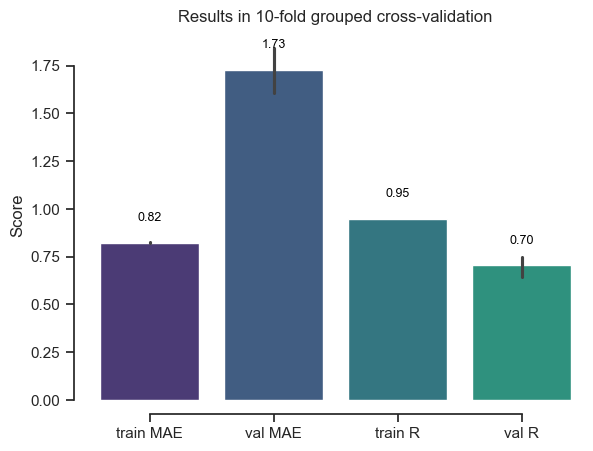

In [19]:
# visualize the results
results_cv_df = pd.DataFrame(results_cv.T, columns=[['train MAE', 'val MAE', 'train R', 'val R']])
sns.set_theme(style="ticks", palette="viridis")
ax = sns.barplot(data=results_cv_df)
plt.title('Results in 10-fold grouped cross-validation')
plt.ylabel('Score')
sns.despine(offset=10, trim=True)
for p in ax.patches:
  ax.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='center', fontsize=9, color='black', xytext=(0, 18), textcoords='offset points')

In [ ]:
# now we can train the model on the train set
model = HistGradientBoostingRegressor(random_state=16)
model.fit(X_train, y_train)

HistGradientBoostingRegressor(random_state=16)

In [22]:
# and we evaluate it on the evaluation set
preds_test = model.predict(X_eval)
test_mae = mean_absolute_error(y_eval, preds_test)
R_test = pearsonr(y_eval, preds_test).statistic
print(f'Test mae: {test_mae}, test R: {R_test}')

Test mae: 1.774943976014765, test R: 0.703009083000216


In [42]:
# now we can check the docking power of the model and compare it with CHEMPLP
poses_eval = poses.loc[poses['Split'] == 'Evaluation']
poses_eval.reset_index(drop=True, inplace=True)
poses_eval['pred RMSD'] = preds_test
# get chemplp score
chemplp = features.loc[poses['Split'] == 'Evaluation', 'PLANTS_CHEMPLP'].to_numpy()
poses_eval['CHEMPLP'] = chemplp
# add success column
poses_eval['Success'] = False
for index in poses_eval.index:
    if poses_eval.at[index, 'RMSD'] <= 2.0:
        poses_eval.at[index, 'Success'] = True

C:\Users\Andrea Cavalli\AppData\Local\Temp\ipykernel_1172\1669989429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poses_eval['pred RMSD'] = preds_test
C:\Users\Andrea Cavalli\AppData\Local\Temp\ipykernel_1172\1669989429.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poses_eval['CHEMPLP'] = chemplp
C:\Users\Andrea Cavalli\AppData\Local\Temp\ipykernel_1172\1669989429.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [ ]:
# CHEMPLP rank
poses_eval['CHEMPLP rank'] = None
for pdb in poses_eval['Protein'].unique():
    return_df = poses_eval.loc[poses_eval['Protein'] == pdb].sort_values('CHEMPLP')
    return_df['CHEMPLP rank'] = None

    for i, pose in enumerate(return_df['Pose']):
        return_df.loc[return_df['Pose'] == pose, 'CHEMPLP rank'] = i + 1
    
    for idx in return_df.index:
        pose = return_df.at[idx, 'Pose']
        poses_eval.loc[poses_eval['Pose'] == pose, 'CHEMPLP rank'] = return_df.at[idx, 'CHEMPLP rank']

# Pred Rank
poses_eval['Pred rank'] = None
for pdb in poses_eval['Protein'].unique():
    return_df = poses_eval.loc[poses_eval['Protein'] == pdb].sort_values('pred RMSD')
    return_df['Pred rank'] = None

    for i, pose in enumerate(return_df['Pose']):
        return_df.loc[return_df['Pose'] == pose, 'Pred rank'] = i + 1
    
    for idx in return_df.index:
        pose = return_df.at[idx, 'Pose']
        poses_eval.loc[poses_eval['Pose'] == pose, 'Pred rank'] = return_df.at[idx, 'Pred rank']

C:\Users\Andrea Cavalli\AppData\Local\Temp\ipykernel_1172\3400168358.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poses_eval['CHEMPLP rank'] = None


In [59]:
# now we compute the docking power and we plot it
pdb_list = list(poses_eval['Protein'].unique())
results_chemplp = pd.DataFrame({
    'PDB': pdb_list,
    1: [None]*len(pdb_list),
    2: [None]*len(pdb_list),
    3: [None]*len(pdb_list),
    4: [None]*len(pdb_list),
    5: [None]*len(pdb_list),
    6: [None]*len(pdb_list),
    7: [None]*len(pdb_list),
    8: [None]*len(pdb_list),
    9: [None]*len(pdb_list),
    10: [None]*len(pdb_list)
})

results_pepscorer = pd.DataFrame({
    'PDB': pdb_list,
    1: [None]*len(pdb_list),
    2: [None]*len(pdb_list),
    3: [None]*len(pdb_list),
    4: [None]*len(pdb_list),
    5: [None]*len(pdb_list),
    6: [None]*len(pdb_list),
    7: [None]*len(pdb_list),
    8: [None]*len(pdb_list),
    9: [None]*len(pdb_list),
    10: [None]*len(pdb_list)
})

# docking power CHEMPLP
for pdb in poses_eval['Protein'].unique():
    for threshold in range(1, 11):
        temp_df = poses_eval.loc[poses_eval['Protein'] == pdb].sort_values('CHEMPLP rank')
        temp_df = temp_df[0:threshold]
        dock_success_n = 0
        for value in temp_df['Success']:
            if value == True:
                dock_success_n += 1
        dock_success = 0
        if dock_success_n > 0:
            dock_success = 1
        results_chemplp.loc[results_chemplp['PDB'] == pdb, threshold] = dock_success

# docking power PepScorer::RMSD
for pdb in poses_eval['Protein'].unique():
    for threshold in range(1, 11):
        temp_df = poses_eval.loc[poses_eval['Protein'] == pdb].sort_values('Pred rank')
        temp_df = temp_df[0:threshold]
        dock_success_n = 0
        for value in temp_df['Success']:
            if value == True:
                dock_success_n += 1
        dock_success = 0
        if dock_success_n > 0:
            dock_success = 1
        results_pepscorer.loc[results_pepscorer['PDB'] == pdb, threshold] = dock_success

dp_chemplp = list(results_chemplp.drop(columns='PDB').mean(axis=0))
dp_pepscorer = list(results_pepscorer.drop(columns='PDB').mean(axis=0))

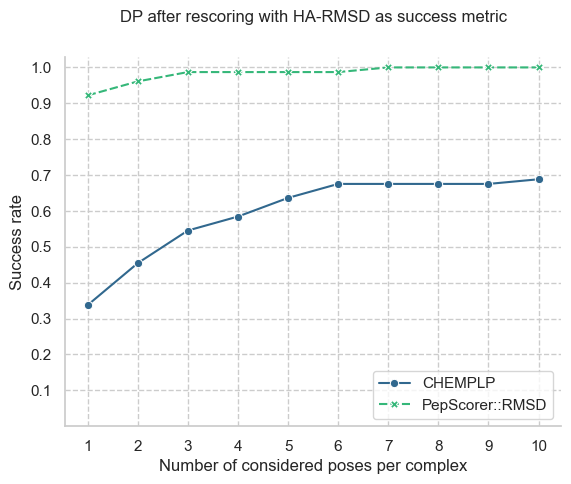

In [60]:
# plot the results
final_results = pd.DataFrame({
    'Number of considered poses per complex': [1,2,3,4,5,6,7,8,9,10] + [1,2,3,4,5,6,7,8,9,10],
    'Success rate': dp_chemplp + dp_pepscorer,
    'Scoring function': ['CHEMPLP']*10 + ['PepScorer::RMSD']*10
})

sns.set_style("whitegrid", {'grid.linestyle': '--'})
ax = sns.lineplot(data=final_results, x='Number of considered poses per complex', y='Success rate', hue='Scoring function', 
                  palette = 'viridis', style='Scoring function', markers=True)
plt.xticks(range(1, 11))
plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.title('DP after rescoring with HA-RMSD as success metric', pad=25)
plt.ylim((0.0, 1.03))
plt.legend(loc='lower right')
sns.despine()
plt.show()